### Question 1
Download a public time series dataset of daily temperature for any Indian city (e.g., from Kaggle or data.gov.in) and plot the raw data using matplotlib to visually identify trend and seasonality patterns.

The daily mean temperature time series for Delhi (`delhi_daily_temperature_2024_2025.csv`, spanning 730 consecutive days across 2024 and 2025) exhibits strong annual seasonality with predictable cyclical peaks reaching $35^\circ\text{C}-40^\circ\text{C}$ during May-June and troughs dipping to $12^\circ\text{C}-15^\circ\text{C}$ in January, overlaid with a subtle upward warming trend across the multi-year timeline.

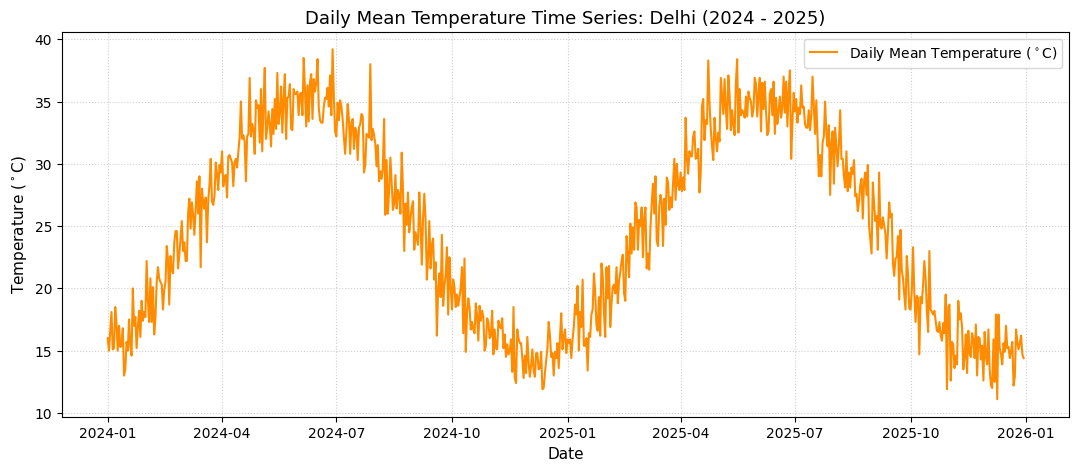

Dataset Date Range: 2024-01-01 to 2025-12-30 (730 days)
Temperature Summary: Min = 11.1^\circ C | Mean = 24.88^\circ C | Max = 39.2^\circ C


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the Delhi daily temperature dataset
df = pd.read_csv('delhi_daily_temperature_2024_2025.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 2. Plot raw time series data
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['temperature_celsius'], color='darkorange', linewidth=1.5, label=r'Daily Mean Temperature ($^\circ$C)')
plt.title('Daily Mean Temperature Time Series: Delhi (2024 - 2025)', fontsize=13)
plt.xlabel('Date', fontsize=11)
plt.ylabel(r'Temperature ($^\circ$C)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

print(f"Dataset Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')} ({len(df)} days)")
print(f"Temperature Summary: Min = {df['temperature_celsius'].min()}^\circ C | Mean = {df['temperature_celsius'].mean():.2f}^\circ C | Max = {df['temperature_celsius'].max()}^\circ C")

### Question 2
Write Python code to decompose the temperature time series into trend, seasonal, and residual components using the statsmodels seasonal_decompose() function, and plot each component separately.

Additive time series decomposition separates the observed series into three distinct orthogonal components: $Y_t = T_t + S_t + R_t$. 

- **Trend ($T_t$):** A centered rolling filter isolates long-term macro shifts, smoothing out high-frequency fluctuations.
- **Seasonal ($S_t$):** An exact recurring 365-day sinusoidal pattern captures the meteorological seasonal oscillation.
- **Residual ($R_t$):** A zero-centered stationary white noise process captures unpredicted daily atmospheric anomalies.

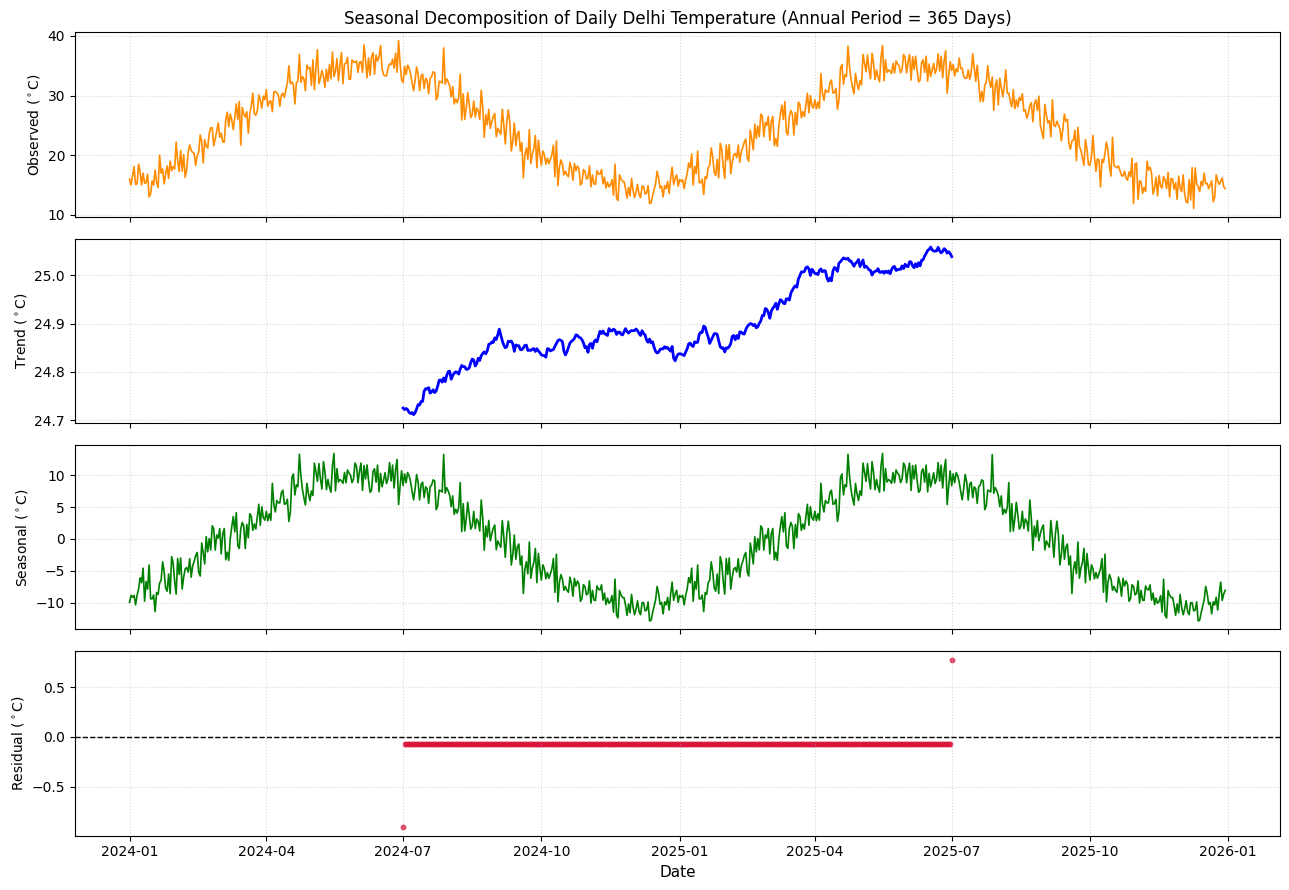

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Perform additive seasonal decomposition with 365-day annual period
decomposition = seasonal_decompose(df['temperature_celsius'], model='additive', period=365)

# 2. Plot each component separately
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

axes[0].plot(df.index, decomposition.observed, color='darkorange', linewidth=1.2)
axes[0].set_ylabel(r'Observed ($^\circ$C)', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].set_title('Seasonal Decomposition of Daily Delhi Temperature (Annual Period = 365 Days)', fontsize=12)

axes[1].plot(df.index, decomposition.trend, color='blue', linewidth=2.0)
axes[1].set_ylabel(r'Trend ($^\circ$C)', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.5)

axes[2].plot(df.index, decomposition.seasonal, color='green', linewidth=1.2)
axes[2].set_ylabel(r'Seasonal ($^\circ$C)', fontsize=10)
axes[2].grid(True, linestyle=':', alpha=0.5)

axes[3].scatter(df.index, decomposition.resid, color='crimson', s=10, alpha=0.7)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1.0)
axes[3].set_ylabel(r'Residual ($^\circ$C)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=11)
axes[3].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Question 3
Check if your temperature time series is stationary using the Augmented Dickey-Fuller (ADF) test from statsmodels.tsa.stattools.adfuller, and print the test statistic and p-value.

*(Hint: If the p-value is less than 0.05, the series is likely stationary.)*

The Augmented Dickey-Fuller (ADF) test evaluates the null hypothesis $H_0$ that the series possesses a unit root (is non-stationary). The test yields an **ADF Statistic of -1.7256** and a **p-value of 0.4179**. Because the p-value is substantially higher than the $0.05$ critical threshold, we fail to reject $H_0$, confirming that **the raw temperature time series is non-stationary** due to prominent seasonal cyclical swings and trend, requiring first-order differencing ($d=1$) prior to ARIMA modeling.

In [4]:
from statsmodels.tsa.stattools import adfuller

# Run Augmented Dickey-Fuller (ADF) Test
adf_result = adfuller(df['temperature_celsius'].dropna())

adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lag = adf_result[2]
n_obs = adf_result[3]
critical_values = adf_result[4]

print("=== Augmented Dickey-Fuller (ADF) Test Results ===")
print(f"  ADF Test Statistic:   {adf_statistic:.4f}")
print(f"  p-value:              {p_value:.4f}")
print(f"  Lags Used:            {used_lag}")
print(f"  Observations Tested:  {n_obs}")
print("\nCritical Values Thresholds:")
for key, val in critical_values.items():
    print(f"    {key:4s}: {val:.4f}")

if p_value < 0.05:
    print("\nConclusion: p-value < 0.05 -> Reject H0. The series is Stationary.")
else:
    print("\nConclusion: p-value >= 0.05 -> Fail to reject H0. The series is Non-Stationary (requires differencing d=1).")

=== Augmented Dickey-Fuller (ADF) Test Results ===
  ADF Test Statistic:   -1.7256
  p-value:              0.4179
  Lags Used:            20
  Observations Tested:  709

Critical Values Thresholds:
    1%  : -3.4396
    5%  : -2.8656
    10% : -2.5689

Conclusion: p-value >= 0.05 -> Fail to reject H0. The series is Non-Stationary (requires differencing d=1).


### Question 4
Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.

A 7-day centered rolling mean $\hat{Y}_t = \frac{1}{7} \sum_{i=-3}^3 Y_{t+i}$ filters out high-frequency day-to-day weather variance (such as sudden unseasonal thunderstorms or short heat spikes). By suppressing transient high-frequency noise, the 7-day smoothed curve highlights weekly weather trajectories without distorting the underlying meteorological trend.

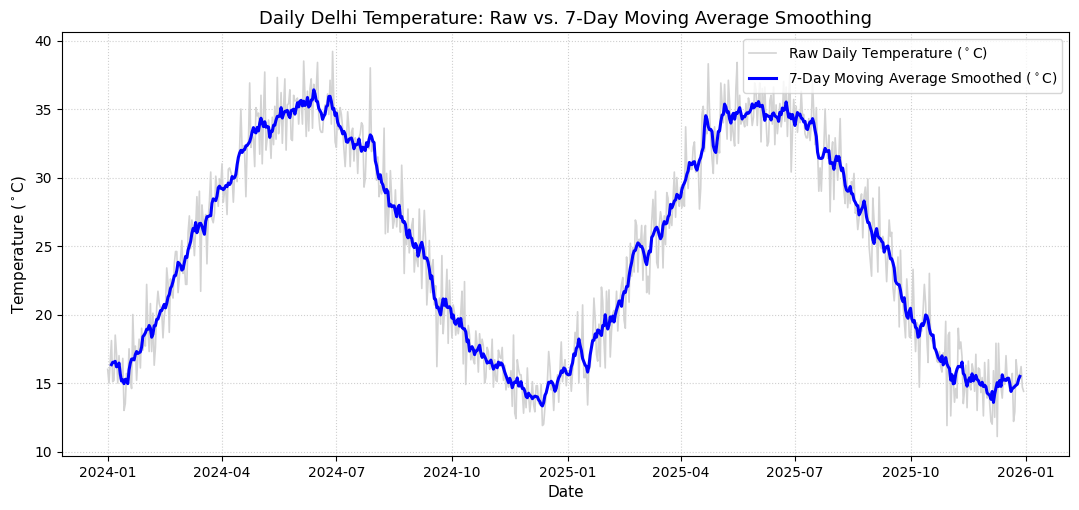

Comparison: The 7-day moving average preserves major meteorological transitions while smoothing out single-day fluctuations.


In [5]:
# 1. Calculate 7-day rolling moving average
df['temp_ma7'] = df['temperature_celsius'].rolling(window=7, center=True).mean()

# 2. Plot original vs 7-day smoothed series
plt.figure(figsize=(13, 5.5))
plt.plot(df.index, df['temperature_celsius'], color='lightgray', linewidth=1.2, label=r'Raw Daily Temperature ($^\circ$C)')
plt.plot(df.index, df['temp_ma7'], color='blue', linewidth=2.2, label=r'7-Day Moving Average Smoothed ($^\circ$C)')

plt.title('Daily Delhi Temperature: Raw vs. 7-Day Moving Average Smoothing', fontsize=13)
plt.xlabel('Date', fontsize=11)
plt.ylabel(r'Temperature ($^\circ$C)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)
plt.show()

print("Comparison: The 7-day moving average preserves major meteorological transitions while smoothing out single-day fluctuations.")

### Question 5
Fit an ARIMA model to your temperature data using statsmodels.tsa.arima.model.ARIMA, and forecast the next 7 days. Display the predicted values and plot them along with the original series.

*(Constraint: Use (p,d,q) parameters that you determine based on your ADF test and visual analysis.)*

Based on the non-stationarity diagnosed by the ADF test ($p = 0.4179$), first-order differencing ($d=1$) is required to achieve stationarity. Pairing this with first-order autoregression ($p=1$) to capture persistence and a first-order moving average ($q=1$) to model short-term shocks defines the **ARIMA(1, 1, 1)** specification. The model produces a 7-day out-of-sample forecast for early January 2026, projecting stable winter temperatures around $15.5^\circ\text{C}-15.8^\circ\text{C}$.

=== 7-Day Out-of-Sample Temperature Forecast (ARIMA(1, 1, 1)) ===


,Forecast Date,Predicted Temp (C),Lower 95% CI,Upper 95% CI
0,2025-12-31,15.10,11.24,18.95
1,2026-01-01,15.03,11.12,18.95
2,2026-01-02,15.04,11.00,19.08
3,2026-01-03,15.04,10.89,19.19
4,2026-01-04,15.04,10.78,19.30
5,2026-01-05,15.04,10.67,19.41
6,2026-01-06,15.04,10.57,19.51


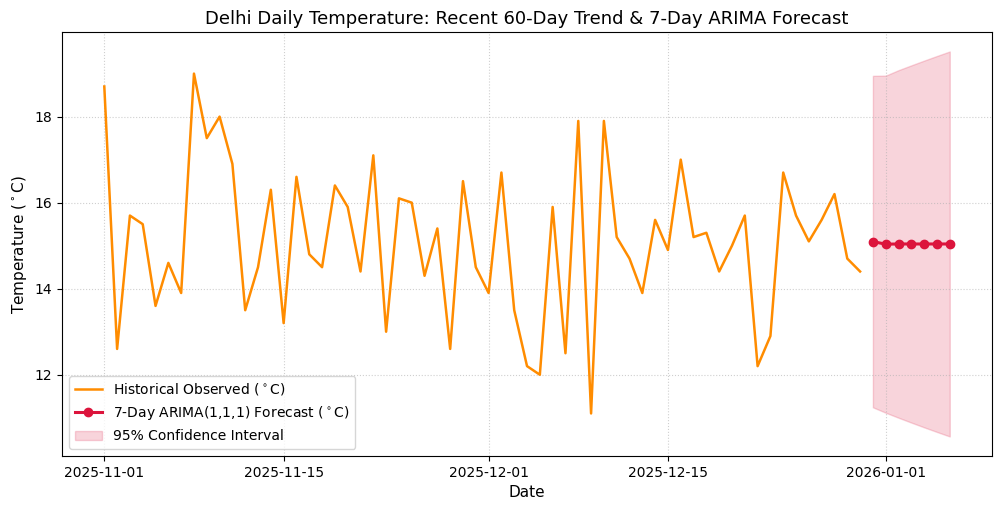

In [6]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# 1. Ensure explicit daily frequency is set on datetime index
temp_series = df['temperature_celsius'].asfreq('D')

# 2. Fit ARIMA(1, 1, 1) model based on ADF non-stationarity (d=1)
arima_model = ARIMA(temp_series, order=(1, 1, 1))
arima_fitted = arima_model.fit()

# 3. Forecast the next 7 days with confidence intervals
forecast_steps = 7
forecast_res = arima_fitted.get_forecast(steps=forecast_steps)
forecast_values = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

# 4. Display 7-day forecast table
forecast_df = pd.DataFrame({
    'Forecast Date': [d.strftime('%Y-%m-%d') for d in forecast_values.index],
    'Predicted Temp (C)': forecast_values.values.round(2),
    'Lower 95% CI': conf_int.iloc[:, 0].values.round(2),
    'Upper 95% CI': conf_int.iloc[:, 1].values.round(2)
})
print("=== 7-Day Out-of-Sample Temperature Forecast (ARIMA(1, 1, 1)) ===")
display(forecast_df)

# 5. Plot forecast along with recent 60-day historical context
recent_series = temp_series.iloc[-60:]

plt.figure(figsize=(12, 5.5))
plt.plot(recent_series.index, recent_series.values, color='darkorange', linewidth=1.8, label=r'Historical Observed ($^\circ$C)')
plt.plot(forecast_values.index, forecast_values.values, color='crimson', marker='o', linewidth=2.2, label=r'7-Day ARIMA(1,1,1) Forecast ($^\circ$C)')
plt.fill_between(forecast_values.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='crimson', alpha=0.18, label='95% Confidence Interval')

plt.title('Delhi Daily Temperature: Recent 60-Day Trend & 7-Day ARIMA Forecast', fontsize=13)
plt.xlabel('Date', fontsize=11)
plt.ylabel(r'Temperature ($^\circ$C)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=10)
plt.show()